In [1]:
import glob
import os
import warnings
from typing import Dict, Optional, Tuple

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from shapely.geometry import Point, box

warnings.filterwarnings("ignore")

# helper functions

import ee

ee.Initialize()

In [ ]:
# Configure matplotlib for publication quality
plt.rcParams.update(
    {
        "font.size": 14,
        "axes.labelsize": 20,
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
    }
)

TRAIT_TITLE = {
    "laie": "LAIe",
    "fapar": "FAPAR",
    "fcover": "FCOVER",
}

DATA_DIR = "../../data-local/merged-v03"


In [3]:
def get_filename(
    trait: str,
    variable: str,
    year: int = 2022,
    resolution: str = "1000m",
    data_dir: str = "data-local/merged-v03",
) -> str:
    """
    Find the appropriate file for given trait, variable, year and resolution

    Args:
        trait: One of 'laie', 'fapar', 'fcover'
        variable: One of 'mean', 'std'
        year: Year to look for
        resolution: '100m' or '1000m'
        data_dir: Base data directory

    Returns:
        Full path to the file
    """
    folder = os.path.join(data_dir, f"results_{resolution}")
    filename = f"{trait}_rtm.mlp.v02_{variable}_{resolution}_s_{year}0101_{year}1231_go_epsg.4326_v03.tif"
    return os.path.join(folder, filename)


def load_raster_data(
    file_path: str, overview_level: int = -3
) -> Tuple[np.ndarray, rasterio.coords.BoundingBox, rasterio.crs.CRS]:
    """
    Load raster data from COG file

    Args:
        file_path: Path to COG file
        overview_level: Which overview level to read (-1 = highest res, -3 = lower res)

    Returns:
        Tuple of (data_array, bounds, crs)
    """
    with rasterio.open(file_path) as dataset:
        # Get scaling parameters
        no_data_value = dataset.nodata
        scaling_factor = dataset.scales[0] if dataset.scales else 1.0

        # Check if overviews exist and select appropriate level
        if dataset.overviews(1):
            overview_levels = dataset.overviews(1)
            if len(overview_levels) >= abs(overview_level):
                ovr_factor = overview_levels[overview_level]
                data = dataset.read(
                    1,
                    out_shape=(
                        dataset.height // ovr_factor,
                        dataset.width // ovr_factor,
                    ),
                )
            else:
                # Use full resolution if not enough overviews
                data = dataset.read(1)
        else:
            # No overviews, use full resolution
            data = dataset.read(1)

        # Apply scaling
        if no_data_value is not None:
            data = np.where(data == no_data_value, np.nan, data)

        data = data.astype(np.float32) * scaling_factor

        return data, dataset.bounds, dataset.crs


def get_cms(trait: str, variable: str):
    """
    Get colormap and normalization for plotting

    Args:
        trait: One of 'laie', 'fapar', 'fcover'
        variable: One of 'mean', 'std', 'count'

    Returns:
        ScalarMappable object with colormap and normalization
    """
    assert trait in ["laie", "fapar", "fcover"]
    assert variable in ["mean", "std", "count"]

    if trait == "laie":
        if variable == "mean":
            return cm.ScalarMappable(
                norm=mcolors.Normalize(vmin=0, vmax=5),
                cmap=mcolors.LinearSegmentedColormap.from_list(
                    "custom_cmap",
                    [
                        "#fffdcd",
                        "#e1cd73",
                        "#aaac20",
                        "#5f920c",
                        "#187328",
                        "#144b2a",
                        "#172313",
                    ],
                    N=256,
                ),
            )
        elif variable == "std":
            return cm.ScalarMappable(
                norm=mcolors.Normalize(vmin=0, vmax=2),
                cmap=mcolors.LinearSegmentedColormap.from_list(
                    "custom_cmap",
                    [
                        "#440154",
                        "#433982",
                        "#30678D",
                        "#218F8B",
                        "#36B677",
                        "#8ED542",
                        "#FDE725",
                    ],
                    N=256,
                ),
            )
    elif trait == "fapar":
        if variable == "mean":
            return cm.ScalarMappable(
                norm=mcolors.Normalize(vmin=0, vmax=1),
                cmap=mcolors.LinearSegmentedColormap.from_list(
                    "custom_cmap",
                    ["#ffffdd", "#e6ad12", "#c53859", "#3a26a1", "#000000"],
                    N=256,
                ),
            )
        elif variable == "std":
            return cm.ScalarMappable(
                norm=mcolors.Normalize(vmin=0, vmax=0.3),
                cmap=mcolors.LinearSegmentedColormap.from_list(
                    "custom_cmap",
                    [
                        "#440154",
                        "#433982",
                        "#30678D",
                        "#218F8B",
                        "#36B677",
                        "#8ED542",
                        "#FDE725",
                    ],
                    N=256,
                ),
            )
    elif trait == "fcover":
        if variable == "mean":
            return cm.ScalarMappable(
                norm=mcolors.Normalize(vmin=0, vmax=1),
                cmap=mcolors.LinearSegmentedColormap.from_list(
                    "custom_cmap",
                    ["#f7fcf5", "#c7e9c0", "#74c476", "#238b45", "#00441b"],
                    N=256,
                ),
            )
        elif variable == "std":
            return cm.ScalarMappable(
                norm=mcolors.Normalize(vmin=0, vmax=0.3),
                cmap=mcolors.LinearSegmentedColormap.from_list(
                    "custom_cmap",
                    [
                        "#440154",
                        "#433982",
                        "#30678D",
                        "#218F8B",
                        "#36B677",
                        "#8ED542",
                        "#FDE725",
                    ],
                    N=256,
                ),
            )

    # Default for count variable for all traits
    if variable == "count":
        return cm.ScalarMappable(
            norm=mcolors.Normalize(vmin=0, vmax=30), cmap="viridis"
        )

    raise ValueError(
        f"Combination of trait {trait} and variable {variable} not recognized."
    )

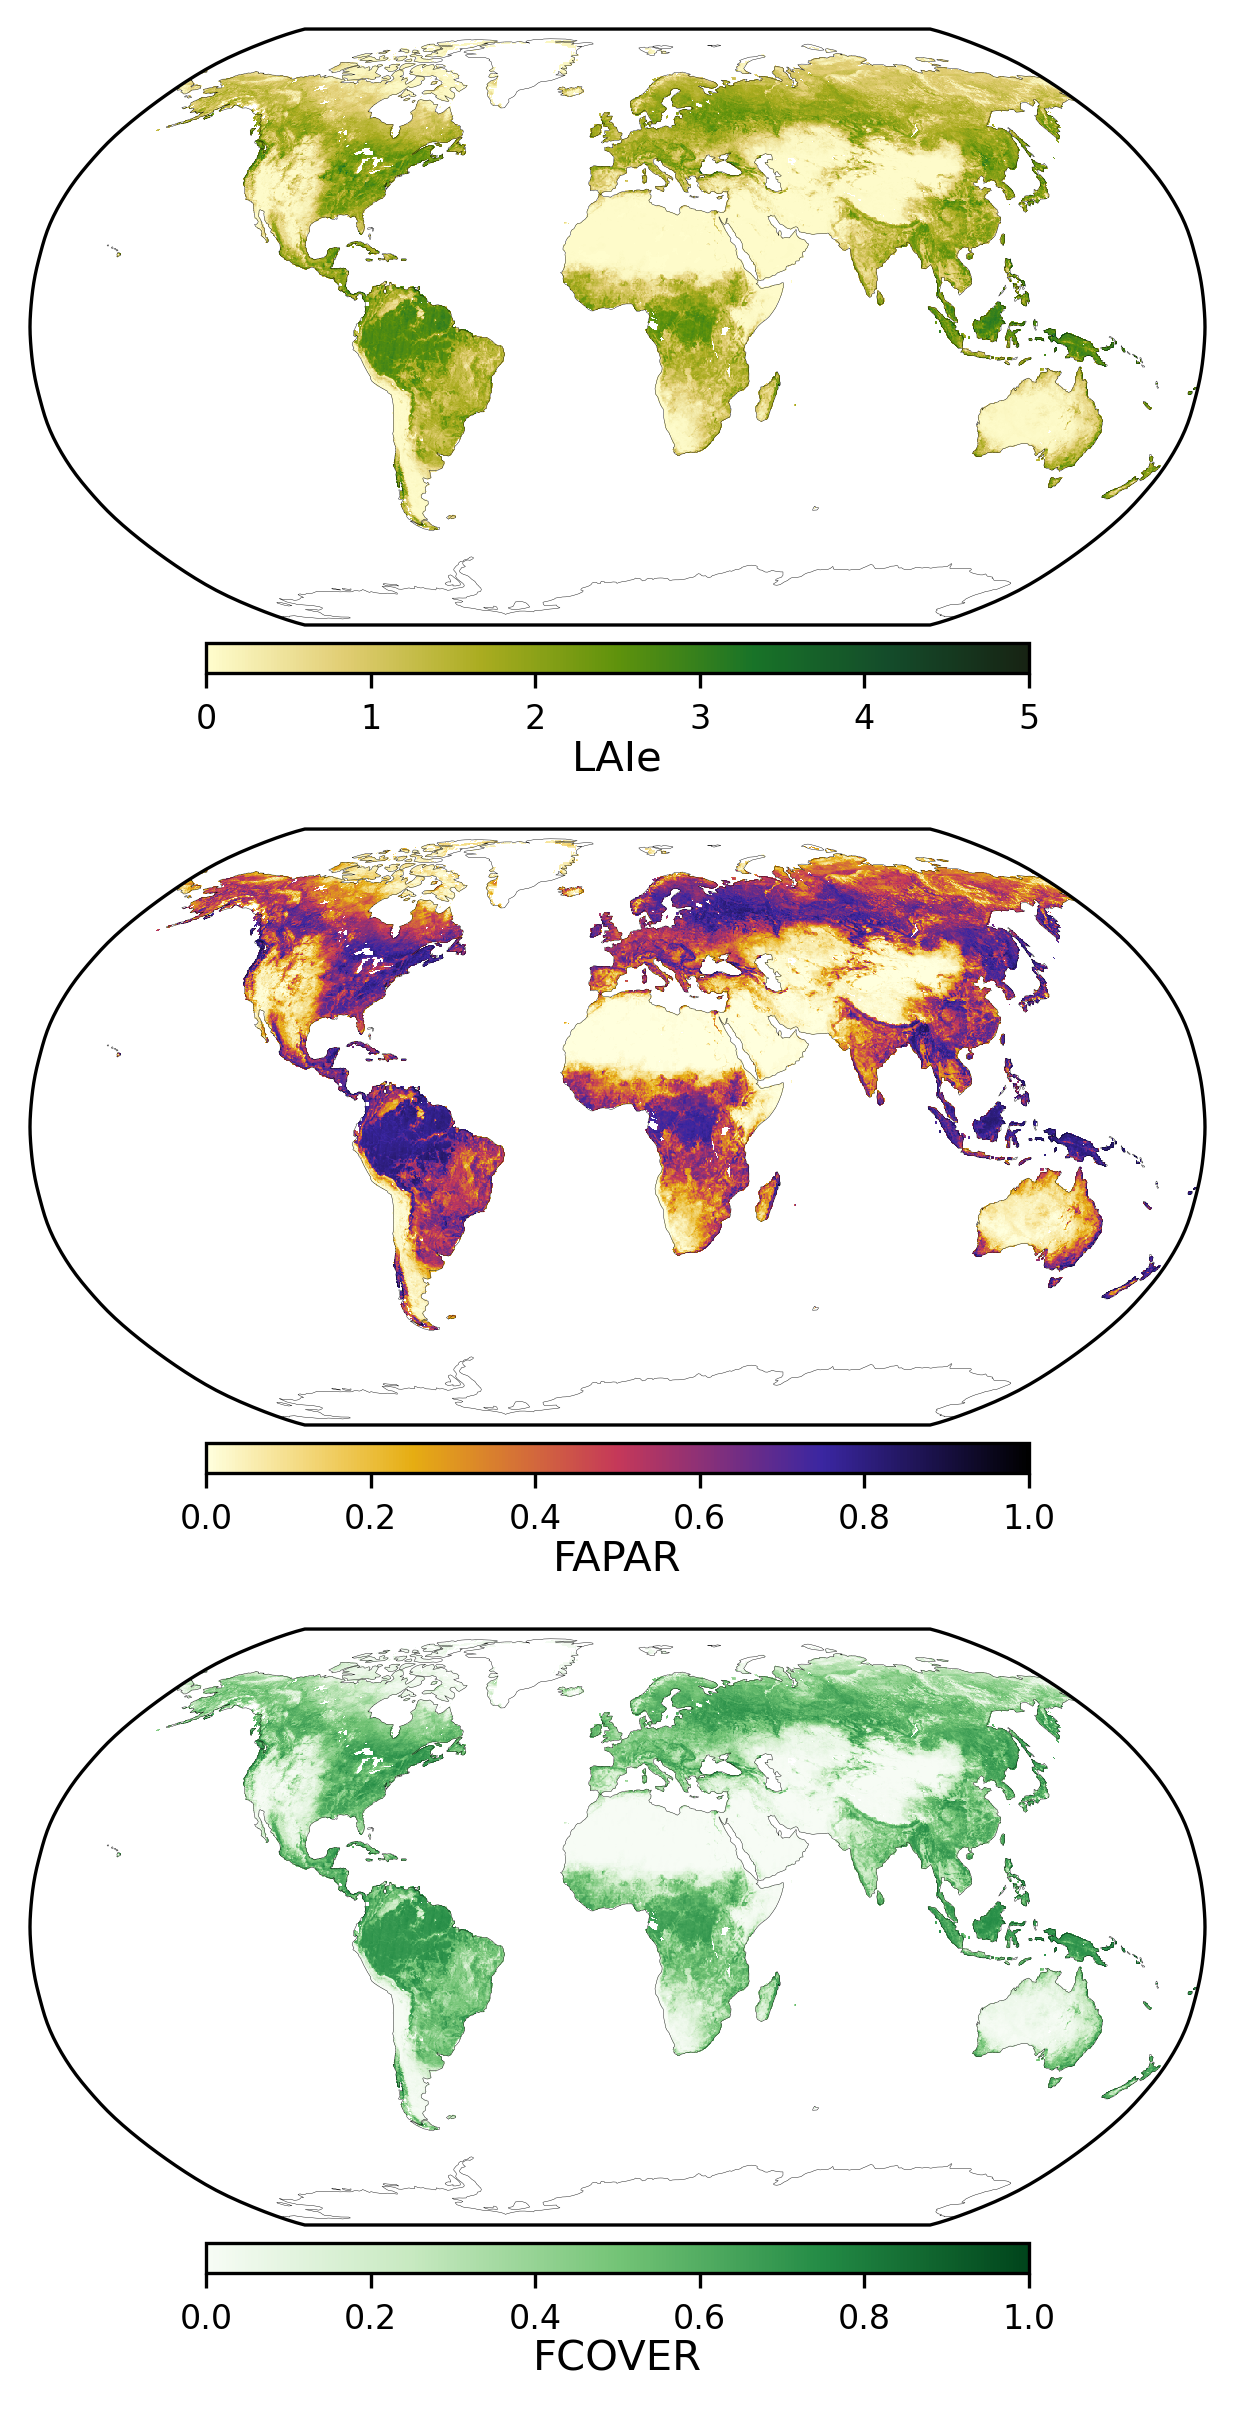

In [4]:
# PLOT: GLOBAL MAPS


fig, axs = plt.subplots(
    3,
    1,
    figsize=(4, 8),
    subplot_kw={"projection": ccrs.Robinson()},
    constrained_layout=True,
)

# Remove axis ticks
for ax in axs.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.subplots_adjust(hspace=0.05)

for i, trait in enumerate(["laie", "fapar", "fcover"]):
    # init GeoAxes with Robinson projection
    # axs[i] = plt.subplot(3, 1, i + 1, projection=ccrs.Robinson())

    file_path = get_filename(trait, "mean", 2022, "100m", DATA_DIR)

    data, bounds, crs = load_raster_data(file_path)

    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]
    cms = get_cms(trait, "mean")

    axs[i].add_feature(cfeature.COASTLINE, linewidth=0.1)
    im = axs[i].imshow(
        data,
        extent=extent,
        transform=ccrs.PlateCarree(),
        cmap=cms.cmap,
        norm=cms.norm,
        interpolation="nearest",
    )

    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    # add narrower horizontal colorbar
    cax = inset_axes(
        axs[i],
        width="70%",  # narrower than full axis
        height="5%",  # colorbar thickness
        loc="lower center",
        bbox_to_anchor=(0, -0.08, 1, 1),  # move below map
        bbox_transform=axs[i].transAxes,
        borderpad=0,
    )

    cbar = plt.colorbar(im, cax=cax, orientation="horizontal")
    cbar.set_label(TRAIT_TITLE[trait], fontsize=10, labelpad=1)
    cbar.ax.tick_params(labelsize=8)

plt.savefig("figure_2_global_maps.png", dpi=300, bbox_inches="tight")
plt.show()

## Plot Example Locations
Right column of Figure 2 consists of three close-up visualisations at 20 meter resolution --> Mean and total standard deviation are displayed 

In [5]:
# helper funtions
import sys


sys.path.append("..")
from utils.plotting_utils import (
    get_geometries,
    get_dimensions_bbox,
    blend_geom_to_img,
    get_color_palettes,
    url_to_image,
)

COLORS = get_color_palettes()


In [6]:
geometries = get_geometries()

point_geoms = geometries["point_geoms_fig2"]
buffered_geoms_bbox = {
    key: geom.buffer(1000).bounds() for key, geom in point_geoms.items()
}

laie_mean = (
    ee.ImageCollection(
        "projects/ee-speckerfelix/assets/open-earth/laie_predictions-mlp_20m_v03"
    )
    .filterDate("2020-01-01", "2020-12-31")
    .select("laie_mean")
)

laie_std = (
    ee.ImageCollection(
        "projects/ee-speckerfelix/assets/open-earth/laie_predictions-mlp_20m_v03"
    )
    .filterDate("2020-01-01", "2020-12-31")
    .select("laie_stdDev")
)

fapar_mean = (
    ee.ImageCollection(
        "projects/ee-speckerfelix/assets/open-earth/fapar_predictions-mlp_20m_v03"
    )
    .filterDate("2024-01-01", "2024-12-31")
    .select("fapar_mean")
)

fapar_std = (
    ee.ImageCollection(
        "projects/ee-speckerfelix/assets/open-earth/fapar_predictions-mlp_20m_v03"
    )
    .filterDate("2024-01-01", "2024-12-31")
    .select("fapar_stdDev")
)

fcover_mean = (
    ee.ImageCollection(
        "projects/ee-speckerfelix/assets/open-earth/fcover_predictions-mlp_20m_v03-figures"
    )
    .filterDate("2022-01-01", "2022-12-31")
    .select("fcover_mean")
)

fcover_std = (
    ee.ImageCollection(
        "projects/ee-speckerfelix/assets/open-earth/fcover_predictions-mlp_20m_v03-figures"
    )
    .filterDate("2022-01-01", "2022-12-31")
    .select("fcover_stdDev")
)

# Correcting undefined variables for markers and sizes
locations = ["destas", "wash", "congo_basin"]
legendsize = 9
labelsize = 9
ticksize = 8

print(get_dimensions_bbox(buffered_geoms_bbox["wash"]))
print(get_dimensions_bbox(buffered_geoms_bbox["destas"]))
print(get_dimensions_bbox(buffered_geoms_bbox["congo_basin"]))

(1994.2867345504462, 2000.5755219799175)
(1990.4937965279432, 1990.012474732836)
(1990.3581121785978, 1989.6967142365677)


In [7]:
laie_mean_url = blend_geom_to_img(
    laie_mean.filterBounds(geometries["destas"]).first().divide(1000),
    geometries["destas"],
    img_vis=COLORS["laie_visparams"],
    geom_vis={"palette": "yellow"},
    width=6,
).getThumbURL(
    {
        "region": buffered_geoms_bbox["destas"],
        "dimensions": 512,
    }
)
print(laie_mean_url)

laie_std_url = blend_geom_to_img(
    laie_std.filterBounds(geometries["destas"]).first().divide(1000),
    geometries["destas"],
    img_vis=COLORS["laie_std_visparams"],
    geom_vis={"palette": "yellow"},
    width=6,
).getThumbURL(
    {
        "region": buffered_geoms_bbox["destas"],
        "dimensions": 512,
    }
)
print(laie_std_url)

fapar_mean_url = (
    fapar_mean.filterBounds(buffered_geoms_bbox["wash"])
    .first()
    .divide(10000)
    .getThumbURL(
        {
            "region": buffered_geoms_bbox["wash"],
            "dimensions": 512,
            **COLORS["fapar_visparams"],
        }
    )
)
print(fapar_mean_url)

fapar_std_url = (
    fapar_std.filterBounds(buffered_geoms_bbox["wash"])
    .first()
    .divide(10000)
    .getThumbURL(
        {
            "region": buffered_geoms_bbox["wash"],
            "dimensions": 512,
            **COLORS["fapar_std_visparams"],
        }
    )
)
print(fapar_std_url)


fcover_mean_url = (
    fcover_mean.filterBounds(buffered_geoms_bbox["congo_basin"])
    .first()
    .divide(10000)
    .getThumbURL(
        {
            "region": buffered_geoms_bbox["congo_basin"],
            "dimensions": 512,
            **COLORS["fcover_visparams"],
        }
    )
)
print(fcover_mean_url)

fcover_std_url = (
    fcover_std.filterBounds(buffered_geoms_bbox["congo_basin"])
    .first()
    .divide(10000)
    .getThumbURL(
        {
            "region": buffered_geoms_bbox["congo_basin"],
            "dimensions": 512,
            **COLORS["fcover_std_visparams"],
        }
    )
)
print(fcover_std_url)

https://earthengine.googleapis.com/v1/projects/gem-eth-analysis/thumbnails/060cf54df914e1f2094f3dccd0b2b26f-be1c12a099eb803e88ad195eb417e616:getPixels
https://earthengine.googleapis.com/v1/projects/gem-eth-analysis/thumbnails/b3cc691f0a36bba21431c3e5dc22870b-b44e8982bcc75299e0b3af757aa7ba17:getPixels
https://earthengine.googleapis.com/v1/projects/gem-eth-analysis/thumbnails/108ba9f7d576246eaac2447a796a981d-267b1b5afae24be6f4489fec41cf3d47:getPixels
https://earthengine.googleapis.com/v1/projects/gem-eth-analysis/thumbnails/a1041c25f6439a155ed0727fbe7bec3c-3d727881e7c97d761f9963c41350e156:getPixels
https://earthengine.googleapis.com/v1/projects/gem-eth-analysis/thumbnails/51c5243607743c4f99f8eed0da9682db-48c5f0c835a978476e0f9d64e361ba41:getPixels
https://earthengine.googleapis.com/v1/projects/gem-eth-analysis/thumbnails/30da14153435fa8873b5fabe6fde0941-1eb1dc976ff03510e62efc7fcf35e10e:getPixels


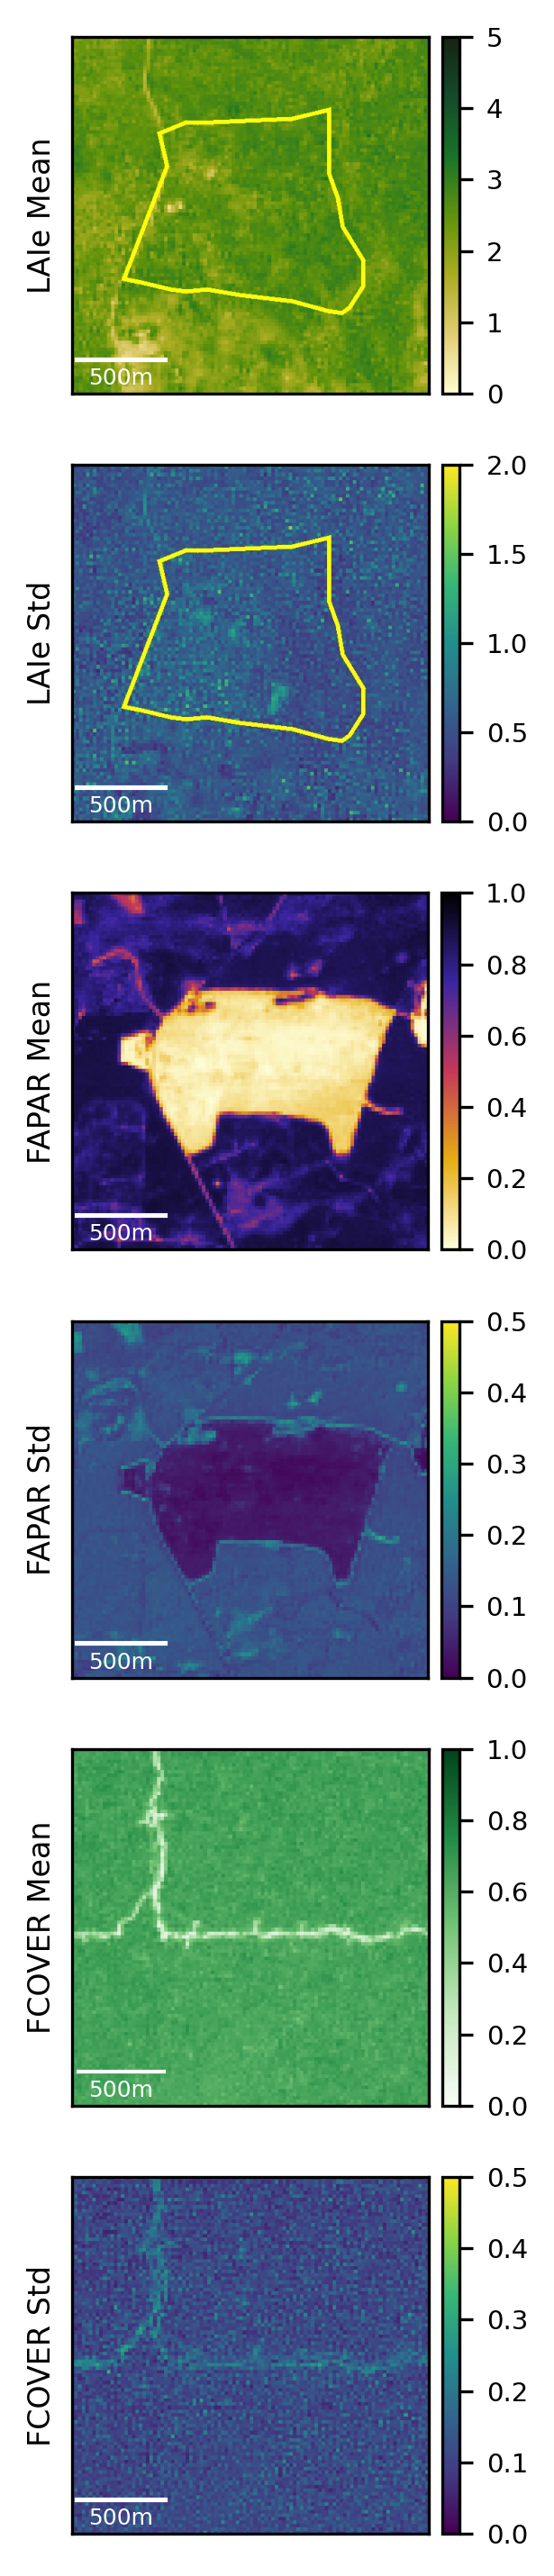

In [8]:
color_bar_tick_size = 7
vertical_label_size = 8
fig, axs = plt.subplots(
    6,
    1,  # Only 2 rows (one for images, one for colorbars)
    figsize=(2, 12),
    # gridspec_kw={"hspace": 0.1, "wspace": 0.2},
)

# Remove axis ticks
for ax in axs.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

#########
# A: LAIe
#########

# LAIe Mean
axs[0].imshow(url_to_image(laie_mean_url))

# Append a **small** color bar axis
divider = make_axes_locatable(axs[0])
cax1 = divider.append_axes("right", size="5%", pad=0.05)  # Reduce space
cb1 = fig.colorbar(
    cm.ScalarMappable(norm=COLORS["laie_norm"], cmap=COLORS["laie_cmap"]),
    cax=cax1,
    orientation="vertical",
)
cb1.ax.set_yticks(np.arange(0, 6, 1))
cb1.ax.tick_params(labelsize=color_bar_tick_size)

# LAIe Std
axs[1].imshow(url_to_image(laie_std_url))

# add scale bar to image
scalebar = AnchoredSizeBar(
    axs[0].transData,
    128,  # 512 pixels = 1990 meters: 512/1990 * 500 = 128.6
    "500m",  # Label for the scale bar
    "lower left",  # Location of the scale bar
    # pad=0.1,
    color="white",
    frameon=False,
    size_vertical=1,
    fontproperties={"size": 6},
)

axs[0].add_artist(scalebar)
# add scale bar to image
scalebar = AnchoredSizeBar(
    axs[1].transData,
    128,  # 512 pixels = 1990 meters: 512/1990 * 500 = 128.6
    "500m",  # Label for the scale bar
    "lower left",  # Location of the scale bar
    # pad=0.1,
    color="white",
    frameon=False,
    size_vertical=1,
    fontproperties={"size": 6},
)
axs[1].add_artist(scalebar)

# Append a **small** color bar axis for LAI std
divider = make_axes_locatable(axs[1])
cax2 = divider.append_axes("right", size="5%", pad=0.05)  # Reduce space
cb2 = fig.colorbar(
    cm.ScalarMappable(norm=COLORS["std_laie_norm"], cmap=COLORS["std_cmap"]),
    cax=cax2,
    orientation="vertical",
)
cb2.ax.tick_params(labelsize=color_bar_tick_size)


#########
# B: FAPAR
#########

# FAPAR Mean
axs[2].imshow(url_to_image(fapar_mean_url))

scalebar = AnchoredSizeBar(
    axs[2].transData,
    128,  # 512 pixels = 1990 meters: 512/1990 * 500 = 128.6
    "500m",  # Label for the scale bar
    "lower left",  # Location of the scale bar
    # pad=0.1,
    color="white",
    frameon=False,
    size_vertical=1,
    fontproperties={"size": 6},
)

axs[2].add_artist(scalebar)


divider = make_axes_locatable(axs[2])
cax1 = divider.append_axes("right", size="5%", pad=0.05)  # Reduce space
cb1 = fig.colorbar(
    cm.ScalarMappable(norm=COLORS["fapar_norm"], cmap=COLORS["fapar_cmap"]),
    cax=cax1,
    orientation="vertical",
)
cb1.ax.set_yticks(np.arange(0, 1.1, 0.2))
cb1.ax.tick_params(labelsize=color_bar_tick_size)

# FAPAR Std
axs[3].imshow(url_to_image(fapar_std_url))

# add scale bar to image
scalebar = AnchoredSizeBar(
    axs[3].transData,
    128,  # 512 pixels = 1990 meters: 512/1990 * 500 = 128.6
    "500m",  # Label for the scale bar
    "lower left",  # Location of the scale bar
    # pad=0.1,
    color="white",
    frameon=False,
    size_vertical=1,
    fontproperties={"size": 6},
)

axs[3].add_artist(scalebar)

divider = make_axes_locatable(axs[3])
cax2 = divider.append_axes("right", size="5%", pad=0.05)  # Reduce space
cb2 = fig.colorbar(
    cm.ScalarMappable(norm=COLORS["std_fapar_norm"], cmap=COLORS["std_cmap"]),
    cax=cax2,
    orientation="vertical",
)
cb2.ax.tick_params(labelsize=color_bar_tick_size)

#########
# C: FCOVER
#########

# FCOVER Mean
axs[4].imshow(url_to_image(fcover_mean_url))


divider = make_axes_locatable(axs[4])
cax1 = divider.append_axes("right", size="5%", pad=0.05)  # Reduce space
cb1 = fig.colorbar(
    cm.ScalarMappable(norm=COLORS["fcover_norm"], cmap=COLORS["fcover_cmap"]),
    cax=cax1,
    orientation="vertical",
)
cb1.ax.set_yticks(np.arange(0, 1.1, 0.2))
cb1.ax.tick_params(labelsize=color_bar_tick_size)

# add scale bar to image
scalebar = AnchoredSizeBar(
    axs[4].transData,
    128,  # 512 pixels = 1990 meters: 512/1990 * 500 = 128.6
    "500m",  # Label for the scale bar
    "lower left",  # Location of the scale bar
    # pad=0.1,
    color="white",
    frameon=False,
    size_vertical=1,
    fontproperties={"size": 6},
)
axs[4].add_artist(scalebar)


# FCOVER Std
axs[5].imshow(url_to_image(fcover_std_url))
# add scale bar to image
scalebar = AnchoredSizeBar(
    axs[5].transData,
    128,  # 512 pixels = 1990 meters: 512/1990 * 500 = 128.6
    "500m",  # Label for the scale bar
    "lower left",  # Location of the scale bar
    # pad=0.1,
    color="white",
    frameon=False,
    size_vertical=1,
    fontproperties={"size": 6},
)

axs[5].add_artist(scalebar)
divider = make_axes_locatable(axs[5])
cax2 = divider.append_axes("right", size="5%", pad=0.05)  # Reduce space
cb2 = fig.colorbar(
    cm.ScalarMappable(norm=COLORS["std_fcover_norm"], cmap=COLORS["std_cmap"]),
    cax=cax2,
    orientation="vertical",
)
cb2.ax.tick_params(labelsize=color_bar_tick_size)


# axs[0].set_title("LAIe (2020)", fontsize=labelsize)
# axs[2].set_title("FAPAR (2024)", fontsize=labelsize)
# axs[4].set_title("FCOVER (2022)", fontsize=labelsize)

axs[0].set_ylabel("LAIe Mean", fontsize=vertical_label_size)
axs[2].set_ylabel("FAPAR Mean", fontsize=vertical_label_size)
axs[4].set_ylabel("FCOVER Mean", fontsize=vertical_label_size)

axs[1].set_ylabel("LAIe Std", fontsize=vertical_label_size)
axs[3].set_ylabel("FAPAR Std", fontsize=vertical_label_size)
axs[5].set_ylabel("FCOVER Std", fontsize=vertical_label_size)


plt.savefig("figure_2_examples.png", dpi=300, bbox_inches="tight")
plt.show()